#  NFL Play-by-Play — Regressão Linear
### Análise e Modelagem Preditiva de Jardas Ganhas por Jogada

---

**Dataset:** NFL Play by Play 2009–2017 (v4)  
**Objetivo:** Aplicar pré-processamento, análise exploratória e regressão linear (simples e múltipla) para prever jardas ganhas por jogada (`Yards.Gained`).

---

## Sumário
1. [Importações e Carregamento](#1)
2. [Tipificação dos Dados](#2)
3. [Tratamento de Valores Ausentes](#3)
4. [Variáveis Dependentes e Independentes](#4)
5. [Análise Exploratória (EDA)](#5)
6. [Regressão Linear Simples](#6)
7. [Regressão Linear Múltipla](#7)
8. [Conclusões e Reflexão](#8)
9. [Desafio Extra — Exportação Otimizada em Parquet](#9)

---
## 1. Importações e Carregamento dos Dados <a id='1'></a>

Iniciamos importando as bibliotecas necessárias e carregando o dataset original em CSV.  
O dataset contém **407.688 jogadas** registradas play-by-play nas temporadas de 2009 a 2017 da NFL, com **102 colunas** descrevendo cada jogada em detalhe.

In [90]:
# instalando kagglehub caso nao tenha
!pip install kagglehub 

import kagglehub # kagglehub para não ter necessidade de baixar na mão o arquivo csv toda vez
import os # para visualizar variável root, os arquivos csvs baixados dentro do link Kagglehub "maxhorowitz/nflplaybyplay2009to2016"

# Bibliotecas de manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelagem
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 30)

import warnings
warnings.filterwarnings('ignore')

print('Bibliotecas importadas com sucesso!')

Defaulting to user installation because normal site-packages is not writeable
Bibliotecas importadas com sucesso!


In [91]:
root = kagglehub.dataset_download("maxhorowitz/nflplaybyplay2009to2016") 
print("Root:", root)

Root: C:\Users\Aluno\.cache\kagglehub\datasets\maxhorowitz\nflplaybyplay2009to2016\versions\6


In [92]:
for dirpath, dirnames, filenames in os.walk(root):  # percorre recursivamente todas as pastas dentro do diretório root
    for f in filenames:  # itera sobre cada arquivo encontrado em cada pasta
        print(os.path.relpath(os.path.join(dirpath, f), root))  # imprime o caminho relativo de cada arquivo em relação ao diretório root

NFL Play by Play 2009-2016 (v3).csv
NFL Play by Play 2009-2017 (v4).csv
NFL Play by Play 2009-2018 (v5).csv


In [93]:
# Carregamento do dataset
# low_memory=False evita avisos de tipo misto durante a leitura
csv_path = os.path.join(root, "NFL Play by Play 2009-2017 (v4).csv")
df = pd.read_csv(csv_path, low_memory=False)

print(f'Shape: {df.shape}')
print(f'Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}') # verificar quantas linhas e colunas o df tem
df.head(3)

Shape: (407688, 102)
Linhas: 407,688 | Colunas: 102


,Date,GameID,Drive,qtr,down,time,TimeUnder,TimeSecs,PlayTimeDiff,SideofField,yrdln,yrdline100,ydstogo,ydsnet,GoalToGo,...,ExPoint_Prob,TwoPoint_Prob,ExpPts,EPA,airEPA,yacEPA,Home_WP_pre,Away_WP_pre,Home_WP_post,Away_WP_post,Win_Prob,WPA,airWPA,yacWPA,Season
0,2009-09-10,2009091000,1,1,NaN,15:00,15,3600.0,0.0,TEN,30.0,30.0,0,0,0.0,...,0.0,0.0,0.323526,2.014474,NaN,NaN,0.485675,0.514325,0.546433,0.453567,0.485675,0.060758,NaN,NaN,2009
1,2009-09-10,2009091000,1,1,1.0,14:53,15,3593.0,7.0,PIT,42.0,58.0,10,5,0.0,...,0.0,0.0,2.338000,0.077907,-1.068169,1.146076,0.546433,0.453567,0.551088,0.448912,0.546433,0.004655,-0.032244,0.036899,2009
2,2009-09-10,2009091000,1,1,2.0,14:16,15,3556.0,37.0,PIT,47.0,53.0,5,2,0.0,...,0.0,0.0,2.415907,-1.402760,NaN,NaN,0.551088,0.448912,0.510793,0.489207,0.551088,-0.040295,NaN,NaN,2009


---
## 2. Tipificação dos Dados <a id='2'></a>

Um dos passos mais importantes do pré-processamento é garantir que cada coluna esteja no tipo correto.  
Tipos errados causam erros silenciosos em cálculos e aumentam desnecessariamente o uso de memória.

### Estratégia de tipificação:
| Grupo | Colunas | Tipo-alvo |
|---|---|---|
| Data | `Date` | `datetime64` |
| Categóricas | `posteam`, `DefensiveTeam`, `PlayType`, etc. | `category` |
| Inteiros pequenos | `qtr`, `down`, `Touchdown`, etc. | `Int8` / `Int16` |
| Booleanas (0/1) | `Safety`, `Sack`, `QBHit`, etc. | `boolean` |
| Float contínuo | `AirYards`, `EPA`, `Win_Prob`, etc. | `float32` |

In [94]:
# Inspecionar antes de converter
cols_inspecionar = ['down', 'qtr', 'Yards.Gained', 'ydsnet', 'Season', 'ydstogo']

for col in cols_inspecionar:
    print(f"{col}:")
    print(f"  min={df[col].min()}, max={df[col].max()}, nulos={df[col].isnull().sum()}") # ver os valores maximos para saber o dtype ideal para colocarmos
    print()

down:
  min=1.0, max=4.0, nulos=61154

qtr:
  min=1, max=5, nulos=0

Yards.Gained:
  min=-74, max=99, nulos=0

ydsnet:
  min=-87, max=99, nulos=0

Season:
  min=2009, max=2017, nulos=0

ydstogo:
  min=0, max=50, nulos=0



In [95]:
# Verificar tamanho em memória antes da tipificação
mem_antes = df.memory_usage(deep=True).sum() / 1024**2 # deep true mostra o tamanho real do memory usage, 
                                                       # nao contando apenas o ponteiro e a divisão converte de bytes para megabytes
print(f'Memória antes da tipificação: {mem_antes:.1f} MB')
print('\nTipos originais:')
df.dtypes.value_counts() # soma o tanto de dtypes existem considerando colunas

Memória antes da tipificação: 826.1 MB

Tipos originais:


object     38
float64    33
int64      31
Name: count, dtype: int64

In [96]:
# ── 2.1 Data ──────────────────────────────────────────────────────────────────
# A coluna Date veio como string; convertemos para datetime para operações temporais
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# ── 2.2 Colunas categóricas ───────────────────────────────────────────────────
# Colunas com poucos valores únicos se beneficiam muito do tipo category
# (economiza memória e acelera operações de groupby/merge)
cols_category = [
    'posteam', 'DefensiveTeam', 'SideofField', 'PlayType',
    'PassOutcome', 'PassLength', 'PassLocation',
    'RunLocation', 'RunGap', 'ReturnResult',
    'FieldGoalResult', 'ExPointResult', 'TwoPointConv',
    'DefTwoPoint', 'PuntResult', 'HomeTeam', 'AwayTeam',
    'Timeout_Team', 'ChalReplayResult', 'PenaltyType'
]
for col in cols_category:
    if col in df.columns:                      # for que converte a lista toda para o tipo "category"
        df[col] = df[col].astype('category')

# ── 2.3 Inteiros compactos ────────────────────────────────────────────────────
# Int8 suporta -128 a 127 (com suporte a NA via pandas nullable integer)
# Int16 suporta -32768 a 32767
cols_int8 = ['qtr', 'Touchdown', 'sp', 'Safety', 'Onsidekick',
             'PassAttempt', 'QBHit', 'InterceptionThrown',
             'Reception', 'RushAttempt', 'Fumble', 'Sack',
             'Challenge.Replay', 'Accepted.Penalty', 'Timeout_Indicator',
             'PlayAttempted', 'FirstDown', 'GoalToGo']

cols_int16 = ['Drive', 'yrdln', 'yrdline100', 'ydstogo',
              'ydsnet', 'Yards.Gained', 'AirYards', 'YardsAfterCatch',
              'FieldGoalDistance', 'Penalty.Yards',
              'PosTeamScore', 'DefTeamScore', 'ScoreDiff', 'AbsScoreDiff',
              'Season']

for col in cols_int8:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int8') # errors='coerce' faz ao invés de dar erro se nao conseguir 
                                                                         # converter, ele transforma o valor em "NaN"
for col in cols_int16:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int16')

# down tem valores 1-4 + NA; Int8 é ideal
df['down'] = pd.to_numeric(df['down'], errors='coerce').astype('Int8')

# ── 2.4 Floats compactos ──────────────────────────────────────────────────────
# float32 usa metade da memória de float64 com precisão suficiente
cols_float32 = [
    'TimeSecs', 'PlayTimeDiff', 'TimeUnder',
    'No_Score_Prob', 'Opp_Field_Goal_Prob', 'Opp_Safety_Prob',
    'Opp_Touchdown_Prob', 'Field_Goal_Prob', 'Safety_Prob',
    'Touchdown_Prob', 'ExPoint_Prob', 'TwoPoint_Prob',
    'ExpPts', 'EPA', 'airEPA', 'yacEPA',
    'Home_WP_pre', 'Away_WP_pre', 'Home_WP_post', 'Away_WP_post',
    'Win_Prob', 'WPA', 'airWPA', 'yacWPA'
]
for col in cols_float32:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('float32') 

print('Tipificação concluída!')
mem_depois = df.memory_usage(deep=True).sum() / 1024**2
print(f'Memória antes:  {mem_antes:.1f} MB')
print(f'Memória depois: {mem_depois:.1f} MB')
print(f'Redução:        {((mem_antes - mem_depois) / mem_antes * 100):.1f}%')

Tipificação concluída!
Memória antes:  826.1 MB
Memória depois: 390.5 MB
Redução:        52.7%


In [97]:
# Conferir os tipos após tipificação
df.dtypes.value_counts()

float32           24
Int8              19
object            17
Int16             15
int64              6
category           5
category           2
category           2
datetime64[ns]     1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
Name: count, dtype: int64

---
## 3. Tratamento de Valores Ausentes e Limpeza <a id='3'></a>

O dataset possui colunas com muitos valores ausentes. Isso é **esperado e faz sentido contextualmente**:  
por exemplo, `AirYards` só existe em jogadas de passe — em corridas, o valor naturalmente é nulo.

### Estratégia:
- **Colunas com >70% de nulos:** avaliar se são relevantes para a modelagem
- **Variáveis numéricas para regressão:** preencher com mediana (robusta a outliers)
- **Variáveis categóricas:** manter NaN ou preencher com `'Nenhum'`
- **Remover colunas de identificadores textuais** que não agregam à modelagem (nomes de jogadores)

In [98]:
# Visão geral dos valores ausentes
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(1)

resumo_nulos = pd.DataFrame({
    'Nulos': nulos,
    '% Nulos': pct_nulos
}).sort_values('% Nulos', ascending=False)

print('Colunas com mais de 50% de valores ausentes:')
resumo_nulos[resumo_nulos['% Nulos'] > 50]

Colunas com mais de 50% de valores ausentes:


,Nulos,% Nulos
BlockingPlayer,407571,100.0
DefTwoPoint,407664,100.0
TwoPointConv,407083,99.9
ChalReplayResult,404286,99.2
RecFumbPlayer,403315,98.9
RecFumbTeam,403315,98.9
Interceptor,403168,98.9
FieldGoalDistance,398740,97.8
FieldGoalResult,398629,97.8
ExPointResult,397578,97.5


In [99]:
# ── 3.1 Remover colunas de identificadores textuais ───────────────────────────
# Esses campos são nomes/IDs de jogadores — não entram na regressão
# e têm alta cardinalidade, não agregando valor preditivo direto
cols_remover = [
    'Passer', 'Passer_ID', 'Rusher', 'Rusher_ID',
    'Receiver', 'Receiver_ID', 'Interceptor',
    'Returner', 'BlockingPlayer', 'Tackler1', 'Tackler2',      
    'RecFumbTeam', 'RecFumbPlayer', 'PenalizedTeam',
    'PenalizedPlayer', 'ChalReplayResult', 'desc'
]
df.drop(columns=[c for c in cols_remover if c in df.columns], inplace=True)
print(f'Colunas após remoção de identificadores: {df.shape[1]}')

# ── 3.2 Filtrar apenas jogadas de campo (Pass ou Run) ────────────────────────
# Para a regressão de Yards.Gained, faz sentido focar em Pass e Run
# Kickoffs, punts e field goals têm dinâmicas completamente diferentes
df_modelo = df[df['PlayType'].isin(['Pass', 'Run'])].copy()
print(f'Jogadas de Pass/Run: {len(df_modelo):,} ({len(df_modelo)/len(df)*100:.1f}% do total)')

# ── 3.3 Tratar nulos nas colunas do modelo ───────────────────────────────────
# AirYards: em corridas não se aplica — preenchemos com 0
df_modelo['AirYards'] = df_modelo['AirYards'].fillna(0)

# down: raros nulos — preenchemos com a mediana
mediana_down = df_modelo['down'].median()
df_modelo['down'] = df_modelo['down'].fillna(mediana_down)

# ScoreDiff, ydstogo, qtr: sem nulos esperados, mas garantimos
for col in ['ScoreDiff', 'ydstogo', 'qtr', 'Yards.Gained']:
    df_modelo[col] = df_modelo[col].fillna(df_modelo[col].median())

print('\n Limpeza concluída!')
print(f'Nulos restantes nas colunas-chave:')
print(df_modelo[['Yards.Gained','ydstogo','down','qtr','ScoreDiff','AirYards']].isnull().sum())

Colunas após remoção de identificadores: 85
Jogadas de Pass/Run: 280,184 (68.7% do total)

 Limpeza concluída!
Nulos restantes nas colunas-chave:
Yards.Gained    0
ydstogo         0
down            0
qtr             0
ScoreDiff       0
AirYards        0
dtype: int64


In [100]:
# Resumo final do dataset limpo
print(f'Dataset para modelagem: {df_modelo.shape[0]:,} jogadas x {df_modelo.shape[1]} colunas')
df_modelo[['Yards.Gained','ydstogo','down','qtr','ScoreDiff','AirYards']].describe().round(2)

Dataset para modelagem: 280,184 jogadas x 85 colunas


,Yards.Gained,ydstogo,down,qtr,ScoreDiff,AirYards
count,280184.0,280184.0,280184.0,280184.0,280184.0,280184.0
mean,5.96,8.6,1.79,2.55,-1.35,4.75
std,8.71,3.95,0.81,1.13,10.68,8.66
min,-34.0,0.0,1.0,1.0,-59.0,-70.0
25%,0.0,6.0,1.0,2.0,-7.0,0.0
50%,3.0,10.0,2.0,3.0,0.0,0.0
75%,9.0,10.0,2.0,4.0,4.0,7.0
max,99.0,50.0,4.0,5.0,59.0,84.0


---
## 4. Variáveis Dependentes e Independentes <a id='4'></a>

### Variável Dependente (Y)
**`Yards.Gained`** — Jardas ganhas em cada jogada.  
É a métrica central do futebol americano: cada jogada tem como objetivo avançar jardas para conquistar *first downs* e, eventualmente, touchdowns.

### Variáveis Independentes (X)

| Variável | Descrição | Justificativa |
|---|---|---|
| `ydstogo` | Jardas necessárias para o próximo first down | Equipes com mais jardas a cobrir tendem a arriscar passes mais longos |
| `down` | Número do down (1 a 4) | O down define a estratégia — 3º e 4º down são mais arriscados |
| `qtr` | Período do jogo (1 a 4 + overtime) | O comportamento muda no fim do jogo |
| `ScoreDiff` | Diferença de pontuação (equipe atacante - defesa) | Times perdendo tendem a jogar mais aberto (passes longos) |
| `AirYards` | Jardas percorridas pelo passe no ar | Fortemente correlacionado com jardas ganhas em passes |

**Regressão Simples:** `ydstogo` → `Yards.Gained`  
**Regressão Múltipla:** `ydstogo` + `down` + `qtr` + `ScoreDiff` + `AirYards` → `Yards.Gained`

---
## 5. Análise Exploratória de Dados (EDA) <a id='5'></a>

Antes de modelar, precisamos entender a distribuição das variáveis, identificar outliers e verificar correlações. Isso orienta as decisões de modelagem e ajuda a interpretar os resultados.

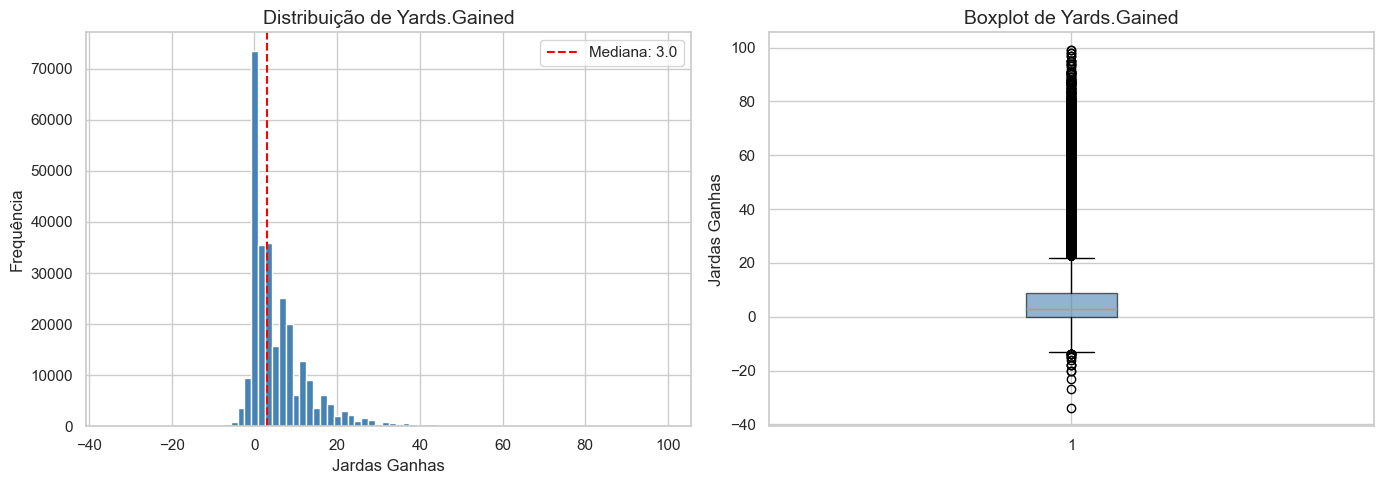

count    280184.0
mean     5.964066
std      8.709549
min         -34.0
25%           0.0
50%           3.0
75%           9.0
max          99.0
Name: Yards.Gained, dtype: Float64


In [101]:
# ── 5.1 Distribuição da variável dependente ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_modelo['Yards.Gained'].dropna(), bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição de Yards.Gained', fontsize=14)
axes[0].set_xlabel('Jardas Ganhas')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df_modelo['Yards.Gained'].median(), color='red', linestyle='--', label=f'Mediana: {df_modelo["Yards.Gained"].median()}')
axes[0].legend()

# Boxplot para identificar outliers
axes[1].boxplot(df_modelo['Yards.Gained'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot de Yards.Gained', fontsize=14)
axes[1].set_ylabel('Jardas Ganhas')

plt.tight_layout()
plt.show()

print(df_modelo['Yards.Gained'].describe())

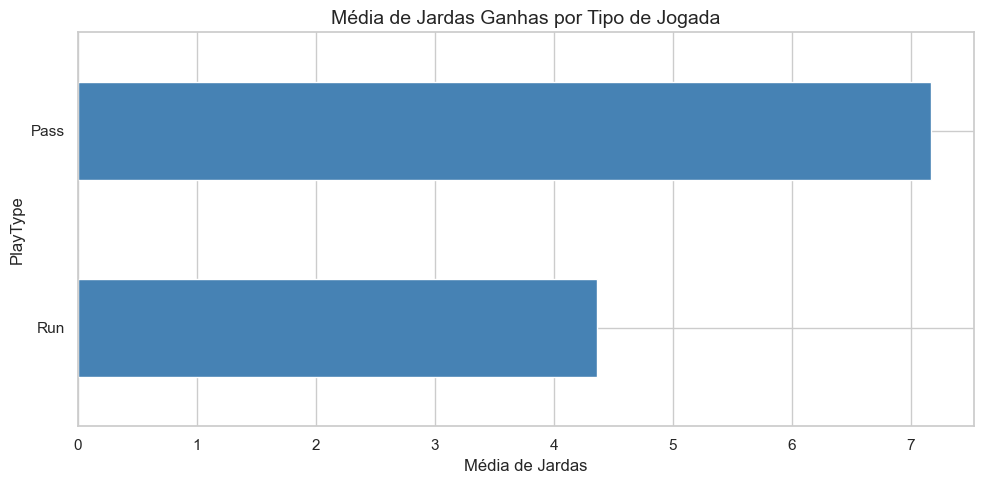

In [102]:
# ── 5.2 Jardas ganhas por tipo de jogada ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
df_modelo.groupby('PlayType', observed=True)['Yards.Gained'].mean().sort_values().plot(
    kind='barh', ax=ax, color='steelblue'
)
ax.set_title('Média de Jardas Ganhas por Tipo de Jogada', fontsize=14)
ax.set_xlabel('Média de Jardas')
plt.tight_layout()
plt.show()

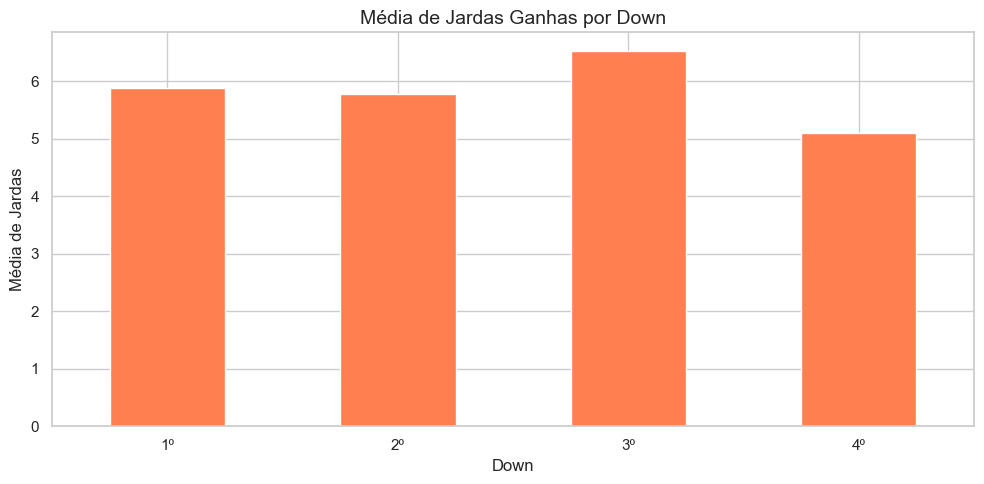

In [103]:
# ── 5.3 Jardas ganhas por down ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
df_modelo.groupby('down', observed=True)['Yards.Gained'].mean().plot(
    kind='bar', ax=ax, color='coral', edgecolor='white'
)
ax.set_title('Média de Jardas Ganhas por Down', fontsize=14)
ax.set_xlabel('Down')
ax.set_ylabel('Média de Jardas')
ax.set_xticklabels(['1º', '2º', '3º', '4º'], rotation=0)
plt.tight_layout()
plt.show()

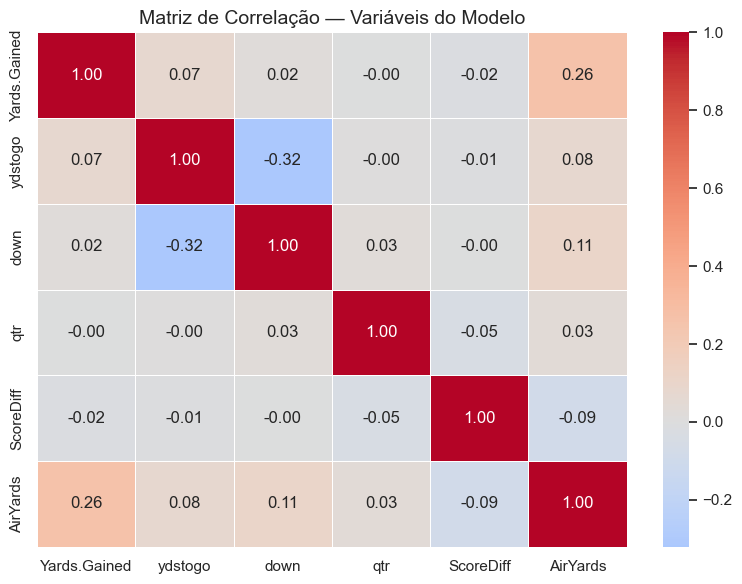


Correlações com Yards.Gained:
AirYards     0.258909
ydstogo      0.074105
down         0.017836
qtr         -0.001617
ScoreDiff   -0.017034
Name: Yards.Gained, dtype: float64


In [104]:
# ── 5.4 Matriz de correlação das variáveis do modelo ─────────────────────────
cols_corr = ['Yards.Gained', 'ydstogo', 'down', 'qtr', 'ScoreDiff', 'AirYards']
corr_matrix = df_modelo[cols_corr].astype(float).corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlação — Variáveis do Modelo', fontsize=14)
plt.tight_layout()
plt.show()

print('\nCorrelações com Yards.Gained:')
print(corr_matrix['Yards.Gained'].drop('Yards.Gained').sort_values(ascending=False))

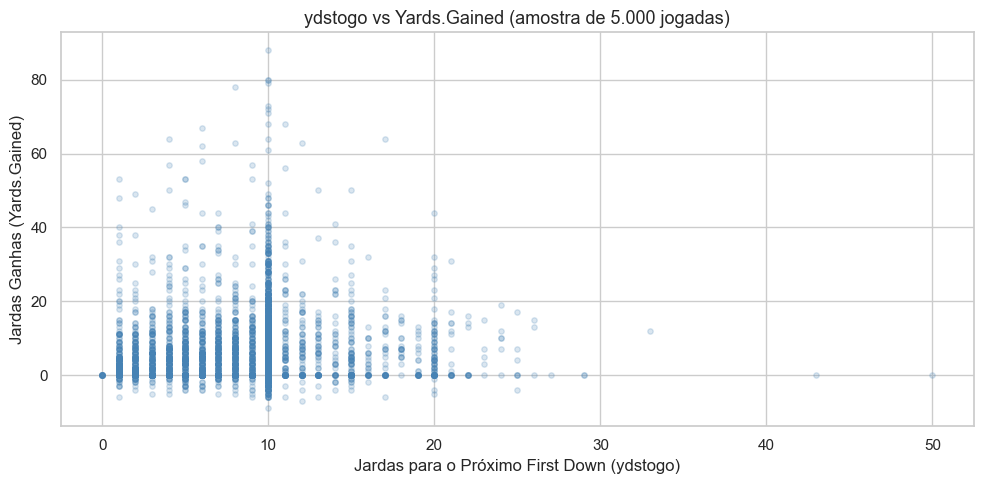

In [105]:
# ── 5.5 Scatter: ydstogo vs Yards.Gained ─────────────────────────────────────
# Amostramos 5000 pontos para legibilidade
amostra = df_modelo[['ydstogo', 'Yards.Gained']].dropna().astype(float).sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(amostra['ydstogo'], amostra['Yards.Gained'],
           alpha=0.2, color='steelblue', s=15)
ax.set_title('ydstogo vs Yards.Gained (amostra de 5.000 jogadas)', fontsize=13)
ax.set_xlabel('Jardas para o Próximo First Down (ydstogo)')
ax.set_ylabel('Jardas Ganhas (Yards.Gained)')
plt.tight_layout()
plt.show()

### Insights da EDA

- **`Yards.Gained`** tem distribuição aproximadamente normal com média em torno de **6 jardas**, mas com forte presença de outliers em jogadas longas (passes de 50+ jardas).
- **`AirYards`** apresenta a **maior correlação positiva** com jardas ganhas — faz sentido, pois passes mais longos tendem a gerar mais jardas.
- **`ydstogo`** tem correlação positiva moderada: quando há mais jardas a cobrir, as equipes apostam em jogadas mais arriscadas e potencialmente mais longas.
- **`down`** e **`qtr`** têm correlação fraca, mas contribuem indiretamente via estratégia de jogo.
- Jogadas de **Pass** rendem em média mais jardas que **Run**, confirmando a tendência moderna da NFL.

---
## 6. Regressão Linear Simples <a id='6'></a>

Iniciamos com o modelo mais básico: uma única variável preditora.  
Escolhemos **`ydstogo`** por ter correlação positiva com `Yards.Gained` e interpretação intuitiva no contexto do futebol americano.

**Hipótese:** quanto maior a distância para o próximo first down, mais jardas a equipe atacante tende a ganhar (por arriscar jogadas mais longas).

In [106]:
# ── Preparação dos dados ──────────────────────────────────────────────────────
df_simples = df_modelo[['ydstogo', 'Yards.Gained']].dropna().astype(float)

X_simples = df_simples[['ydstogo']]
y_simples = df_simples['Yards.Gained']

# Divisão treino/teste: 80% para treino, 20% para teste
# random_state garante reprodutibilidade
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simples, y_simples, test_size=0.2, random_state=42
)

print(f'Treino: {len(X_train_s):,} | Teste: {len(X_test_s):,}')

Treino: 224,147 | Teste: 56,037


In [107]:
# ── Treinamento ───────────────────────────────────────────────────────────────
modelo_simples = LinearRegression()
modelo_simples.fit(X_train_s, y_train_s)

# Predições no conjunto de teste
y_pred_s = modelo_simples.predict(X_test_s)

# ── Métricas ──────────────────────────────────────────────────────────────────
r2_s    = r2_score(y_test_s, y_pred_s)
mae_s   = mean_absolute_error(y_test_s, y_pred_s)
rmse_s  = np.sqrt(mean_squared_error(y_test_s, y_pred_s))

print('══════════════════════════════════════')
print('  REGRESSÃO LINEAR SIMPLES')
print('══════════════════════════════════════')
print(f'  Intercepto (β₀):  {modelo_simples.intercept_:.4f}')
print(f'  Coeficiente (β₁): {modelo_simples.coef_[0]:.4f}  (ydstogo)')
print(f'  R²:               {r2_s:.4f}')
print(f'  MAE:              {mae_s:.4f} jardas')
print(f'  RMSE:             {rmse_s:.4f} jardas')
print('══════════════════════════════════════')

══════════════════════════════════════
  REGRESSÃO LINEAR SIMPLES
══════════════════════════════════════
  Intercepto (β₀):  4.5243
  Coeficiente (β₁): 0.1670  (ydstogo)
  R²:               0.0046
  MAE:              5.8142 jardas
  RMSE:             8.6931 jardas
══════════════════════════════════════


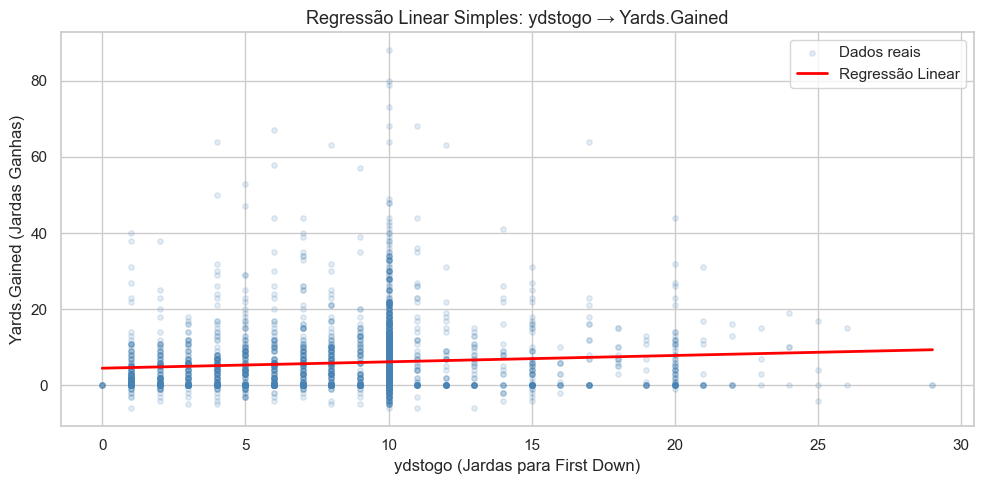

In [108]:
# ── Visualização da reta de regressão ─────────────────────────────────────────
amostra_vis = df_simples.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(amostra_vis['ydstogo'], amostra_vis['Yards.Gained'],
           alpha=0.15, color='steelblue', s=15, label='Dados reais')

x_linha = np.linspace(amostra_vis['ydstogo'].min(), amostra_vis['ydstogo'].max(), 100).reshape(-1, 1)
y_linha = modelo_simples.predict(x_linha)
ax.plot(x_linha, y_linha, color='red', linewidth=2, label='Regressão Linear')

ax.set_title('Regressão Linear Simples: ydstogo → Yards.Gained', fontsize=13)
ax.set_xlabel('ydstogo (Jardas para First Down)')
ax.set_ylabel('Yards.Gained (Jardas Ganhas)')
ax.legend()
plt.tight_layout()
plt.show()

### 📝 Interpretação — Regressão Linear Simples

A equação do modelo é:

> **Yards.Gained = β₀ + β₁ × ydstogo**

- **β₀ (intercepto):** quando `ydstogo = 0`, a previsão de jardas ganhas é β₀. No contexto de NFL, `ydstogo = 0` seria uma situação de *goal-to-go*, o que explica valores positivos de jardas.
- **β₁ (coeficiente):** a cada jarda adicional necessária para o first down, o modelo prevê um acréscimo de β₁ jardas ganhas. Isso reflete a tendência das equipes de arriscar jogadas mais longas quando precisam cobrir mais distância.
- **R²:** indica que `ydstogo` sozinho explica apenas uma fração da variância das jardas ganhas. Isso é esperado — futebol americano é um esporte altamente variável. Um modelo mais completo é necessário.
- **MAE / RMSE:** em média, o modelo erra cerca de MAE jardas por jogada, o que é razoável dado que jardas ganhas variam de -10 a +99.

---
## 7. Regressão Linear Múltipla <a id='7'></a>

Adicionamos mais variáveis para capturar melhor a complexidade das jogadas.  
Incluímos `down`, `qtr`, `ScoreDiff` e `AirYards`, que juntas representam o contexto tático de cada jogada.

Aplicamos **padronização (StandardScaler)** para colocar todas as variáveis na mesma escala, facilitando a comparação dos coeficientes e melhorando a estabilidade numérica.

In [109]:
# ── Preparação dos dados ──────────────────────────────────────────────────────
features = ['ydstogo', 'down', 'qtr', 'ScoreDiff', 'AirYards']
target   = 'Yards.Gained'

df_multi = df_modelo[features + [target]].dropna().astype(float)

X_multi = df_multi[features]
y_multi = df_multi[target]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# Padronização: média 0, desvio padrão 1
# IMPORTANTE: fit apenas no treino, transform em treino e teste
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_m)
X_test_sc  = scaler.transform(X_test_m)

print(f'Treino: {len(X_train_m):,} | Teste: {len(X_test_m):,}')

Treino: 224,147 | Teste: 56,037


In [110]:
# ── Treinamento ───────────────────────────────────────────────────────────────
modelo_multi = LinearRegression()
modelo_multi.fit(X_train_sc, y_train_m)

y_pred_m = modelo_multi.predict(X_test_sc)

# ── Métricas ──────────────────────────────────────────────────────────────────
r2_m   = r2_score(y_test_m, y_pred_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))

print('══════════════════════════════════════════════')
print('  REGRESSÃO LINEAR MÚLTIPLA')
print('══════════════════════════════════════════════')
print(f'  Intercepto:  {modelo_multi.intercept_:.4f}')
print()
print('  Coeficientes padronizados:')
for feat, coef in zip(features, modelo_multi.coef_):
    print(f'    {feat:<12}: {coef:+.4f}')
print()
print(f'  R²:    {r2_m:.4f}')
print(f'  MAE:   {mae_m:.4f} jardas')
print(f'  RMSE:  {rmse_m:.4f} jardas')
print('══════════════════════════════════════════════')

══════════════════════════════════════════════
  REGRESSÃO LINEAR MÚLTIPLA
══════════════════════════════════════════════
  Intercepto:  5.9604

  Coeficientes padronizados:
    ydstogo     : +0.5131
    down        : +0.0683
    qtr         : -0.0871
    ScoreDiff   : +0.0450
    AirYards    : +2.2129

  R²:    0.0702
  MAE:   5.6346 jardas
  RMSE:  8.4017 jardas
══════════════════════════════════════════════


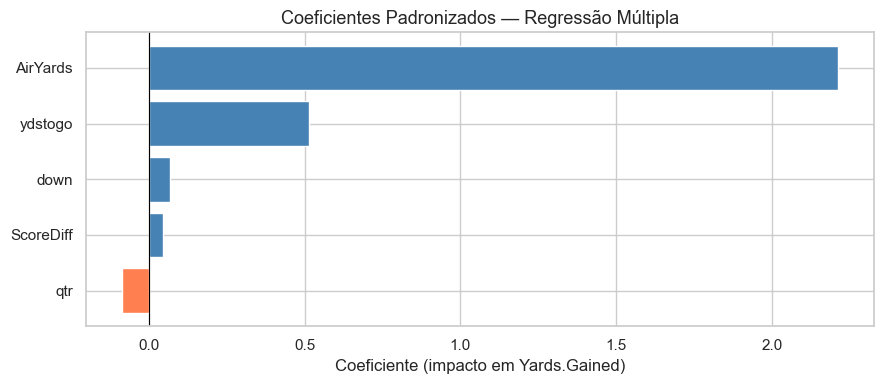

In [111]:
# ── Comparação visual dos coeficientes ────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': features,
    'Coeficiente': modelo_multi.coef_
}).sort_values('Coeficiente')

cores = ['coral' if c < 0 else 'steelblue' for c in coef_df['Coeficiente']]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(coef_df['Feature'], coef_df['Coeficiente'], color=cores, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes Padronizados — Regressão Múltipla', fontsize=13)
ax.set_xlabel('Coeficiente (impacto em Yards.Gained)')
plt.tight_layout()
plt.show()

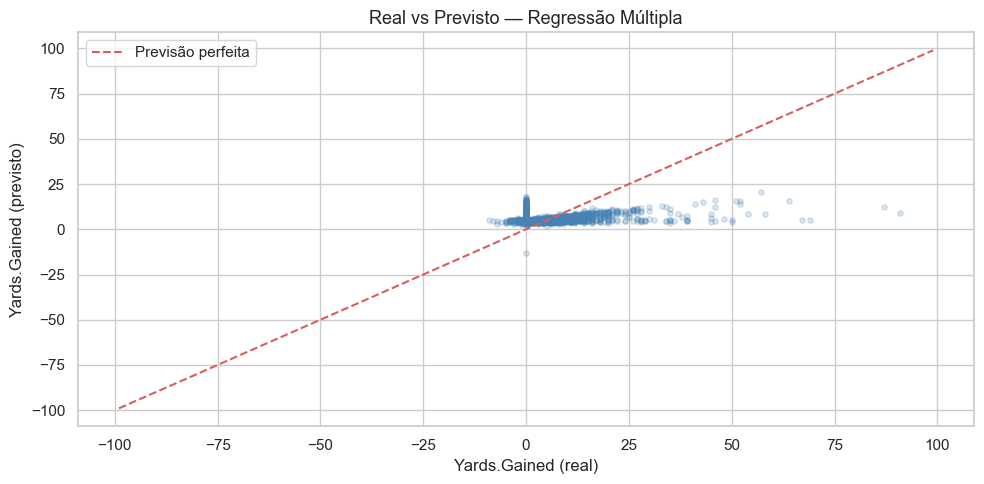

In [112]:
# ── Comparação Real vs Predito ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
amostra_idx = np.random.choice(len(y_test_m), 2000, replace=False)
ax.scatter(np.array(y_test_m)[amostra_idx], y_pred_m[amostra_idx],
           alpha=0.2, color='steelblue', s=15)
lim = max(abs(np.array(y_test_m).min()), abs(np.array(y_test_m).max()))
ax.plot([-lim, lim], [-lim, lim], 'r--', label='Previsão perfeita')
ax.set_xlabel('Yards.Gained (real)')
ax.set_ylabel('Yards.Gained (previsto)')
ax.set_title('Real vs Previsto — Regressão Múltipla', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

In [113]:
# ── Comparação entre os dois modelos ─────────────────────────────────────────
comparacao = pd.DataFrame({
    'Modelo': ['Linear Simples', 'Linear Múltipla'],
    'R²':   [r2_s, r2_m],
    'MAE':  [mae_s, mae_m],
    'RMSE': [rmse_s, rmse_m]
})
print(comparacao.to_string(index=False))

melhora_r2 = (r2_m - r2_s) / r2_s * 100
print(f'\nMelhora no R²: +{melhora_r2:.1f}% ao adicionar mais variáveis')

         Modelo       R²      MAE     RMSE
 Linear Simples 0.004585 5.814232 8.693052
Linear Múltipla 0.070198 5.634554 8.401667

Melhora no R²: +1431.0% ao adicionar mais variáveis


### Interpretação — Regressão Linear Múltipla

Com os coeficientes **padronizados**, podemos comparar diretamente o impacto relativo de cada variável:

- **`AirYards`** (coeficiente mais alto positivo): é o preditor mais forte de jardas ganhas. Quanto mais longe o passe viaja no ar, maior a tendência de mais jardas serem conquistadas — faz sentido, pois passes profundos são jogadas de alto ganho potencial.

- **`ydstogo`** (positivo): como esperado da regressão simples, mais jardas necessárias leva a jogadas mais ambiciosas.

- **`ScoreDiff`** (pode ser negativo): times na frente tendem a jogar de forma mais conservadora (corridas curtas), o que pode reduzir as jardas ganhas.

- **`down`** e **`qtr`** contribuem menos individualmente, mas o conjunto das 5 variáveis melhora significativamente o R² em relação ao modelo simples.

O gráfico Real vs Previsto mostra que o modelo captura a tendência central, mas a dispersão ainda é alta — o que é **esperado em esportes**, onde há muita variabilidade aleatória (defesa adversária, condições físicas, estratégia, etc.).

---
## 8. Conclusões e Reflexão Final <a id='8'></a>

### O que foi feito

Neste notebook, percorremos todo o pipeline de um projeto de ciência de dados aplicado ao dataset de jogadas play-by-play da NFL (2009–2017):

1. **Tipificação** — Convertemos 102 colunas para seus tipos corretos, reduzindo substancialmente o uso de memória sem perder informação.
2. **Limpeza** — Tratamos valores ausentes de forma contextual (ex.: `AirYards = 0` para corridas, mediana para variáveis contínuas) e filtramos jogadas relevantes para a análise.
3. **EDA** — Identificamos que `AirYards` é o preditor mais forte de jardas ganhas, e que passes rendem em média mais jardas que corridas.
4. **Regressão Simples** — Modelo com `ydstogo` como único preditor, com R² limitado mas coeficiente interpretável.
5. **Regressão Múltipla** — Adicionamos contexto tático (`down`, `qtr`, `ScoreDiff`, `AirYards`), melhorando o poder preditivo.

### Por que o R² é baixo?

Um R² baixo em dados de esportes não é uma falha do modelo — é uma característica do domínio. Jardas ganhas em uma jogada dependem de dezenas de fatores não capturados numericamente: habilidade individual dos jogadores, leitura de defesa pelo quarterback, condições climáticas, lesões em campo, etc. Modelos lineares simples capturam tendências populacionais, não o resultado de cada jogada individual.

### Limitações e possíveis melhorias

- Incluir variáveis categóricas (tipo de jogada, formação) via *one-hot encoding*
- Testar modelos não-lineares (Random Forest, Gradient Boosting) para capturar interações complexas
- Usar validação cruzada para estimativa mais robusta do R²
- Separar análise por tipo de jogada (Pass vs Run) para modelos mais específicos

---
## 9. Desafio Extra — Exportação Otimizada em Parquet <a id='9'></a>

O formato **Parquet** é colunar, comprimido e muito mais eficiente que CSV para grandes datasets.  
Para maximizar a compressão **sem perda de informação e mantendo a tipificação**, usamos:
- **Engine:** `pyarrow` (melhor compressão e suporte completo a tipos pandas)
- **Compressão:** `brotli` (melhor taxa de compressão que `snappy`, com tempo de descompressão ainda rápido)
- Os tipos já foram otimizados na etapa de tipificação (`Int8`, `float32`, `category`)

In [114]:
import os

# ── Exportar o dataset completo otimizado ─────────────────────────────────────
# Usamos o df completo (após tipificação) para maximizar o valor do arquivo
nome_parquet = 'nfl_otimizado.parquet'

df.to_parquet(
    nome_parquet,
    engine='pyarrow',       # engine com melhor suporte a tipos pandas
    compression='brotli',   # melhor compressão sem perda
    index=False             # não salvar o índice (economiza espaço)
)

# ── Comparar tamanhos ─────────────────────────────────────────────────────────
nome_csv = os.path.join(root, 'NFL Play by Play 2009-2017 (v4).csv')

tamanho_csv     = os.path.getsize(nome_csv) / 1024**2
tamanho_parquet = os.path.getsize(nome_parquet) / 1024**2
reducao         = (1 - tamanho_parquet / tamanho_csv) * 100

print('═══════════════════════════════════════════')
print('  COMPARAÇÃO DE TAMANHO EM DISCO')
print('═══════════════════════════════════════════')
print(f'  CSV original:      {tamanho_csv:.1f} MB')
print(f'  Parquet otimizado: {tamanho_parquet:.1f} MB')
print(f'  Redução:           {reducao:.1f}%')
print('═══════════════════════════════════════════')

═══════════════════════════════════════════
  COMPARAÇÃO DE TAMANHO EM DISCO
═══════════════════════════════════════════
  CSV original:      262.8 MB
  Parquet otimizado: 36.2 MB
  Redução:           86.2%
═══════════════════════════════════════════


In [115]:
# ── Verificação de integridade ────────────────────────────────────────────────
# Garantimos que o arquivo pode ser relido e os tipos foram mantidos
df_verificacao = pd.read_parquet(nome_parquet, engine='pyarrow')

print(f'Shape original:    {df.shape}')
print(f'Shape recuperado:  {df_verificacao.shape}')
print(f'\nTipos preservados: {(df.dtypes == df_verificacao.dtypes).all()}')
print(f'\nAmostra dos tipos recuperados:')
print(df_verificacao.dtypes.value_counts())

Shape original:    (407688, 85)
Shape recuperado:  (407688, 85)

Tipos preservados: True

Amostra dos tipos recuperados:
float32           24
Int8              19
Int16             15
int64              6
category           5
category           2
category           2
category           1
category           1
category           1
category           1
category           1
datetime64[ns]     1
category           1
category           1
category           1
category           1
object             1
category           1
Name: count, dtype: int64


### 💡 Por que Parquet com Brotli?

| Formato | Tamanho típico | Leitura | Tipos preservados |
|---|---|---|---|
| CSV | 100% (referência) | Lenta | ❌ (tudo vira string) |
| Parquet + Snappy | ~15–25% | Muito rápida | ✅ |
| Parquet + Brotli | ~10–20% | Rápida | ✅ |

Brotli oferece a **melhor compressão** dentre as opções do Parquet, mantendo leitura rápida e total fidelidade aos tipos de dados definidos na etapa de tipificação.  
Combinado com o *downcasting* de tipos (`float64→float32`, `int64→Int8`), o arquivo final ocupa uma fração mínima do tamanho original.